<a href="https://colab.research.google.com/github/cristinasarakefi-art/TugasAkhirS1/blob/main/Penelitian%2016%20ini%20yg%20FIXX%20Untitled41.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from collections import Counter
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from google.colab import files

In [2]:
#1. Upload & Load Data
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name, sep=None, engine='python')

# Cleansing spasi tersembunyi pada header & teks
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# Konversi IPK ke format desimal float
df['IPK Semester 3'] = df['IPK Semester 3'].str.replace(',', '.').astype(float)

display(HTML("<b>=== BAGIAN 1: DATASET BERHASIL DI-LOAD ===</b>"))
display(HTML(f"Total Jumlah Data: <b>{len(df)} baris</b>"))
display(df.head())

Saving Data Mentah Penelitian Skripsi 5.csv to Data Mentah Penelitian Skripsi 5.csv


,Nama Lengkap,Bidang Minat,IPK Semester 3,Nilai mata kuliah Dasar Tenaga Listrik,Nilai mata kuliah Dasar Teknik Telekomunikasi,Nilai mata kuliah Dasar Pemrograman Komputer,Nilai Skor Minat TTL,Nilai Skor Minat TTT,Nilai Skor Minat TKK
0,Kristina Sara Sunia Kefi,Teknik Komputer & Kendali,2.79,A,C,C,15,15,29
1,Kartini Riyani Boni Geti,Teknik Telekomunikasi,2.79,A-,B-,C+,17,27,25
2,Fransiska Romana Dua Yustin Nellu,Teknik Telekomunikasi,2.73,A,B+,AB,30,35,32
3,JUFRIDSON LAY WOHE,Teknik Komputer & Kendali,2.48,AB,B-,C,20,7,33
4,Epin Modjo,Teknik Komputer & Kendali,2.91,B+,B-,AB,29,21,35


In [3]:
#2. Pemisah Dataset
kolom_nama = 'Nama Lengkap'
kolom_target = 'Bidang Minat'
kolom_fitur = [c for c in df.columns if c not in [kolom_nama, kolom_target]]

# Sequential Split (1-80 Data Latih, 81-100 Data Uji)
train_idx = df.index[:80]
test_idx = df.index[80:]

df_train = df.loc[train_idx].copy()
df_test = df.loc[test_idx].copy()

df_summary = pd.DataFrame({
    'Jenis Data': ['Data Latih (80%)', 'Data Uji (20%)', 'Total Dataset'],
    'Rentang Baris': ['Baris 1 - 80 (Kristina s.d. Yuvensia)', 'Baris 81 - 100 (Victoria s.d. Lorensius)', '1 - 100'],
    'Jumlah Baris': [len(df_train), len(df_test), len(df)]
})

display(HTML("<br><b>=== BAGIAN 2: HASIL PEMISAHAN DATASET (80:20 BERURUTAN) ===</b>"))
display(df_summary.style.hide(axis='index'))
display(HTML("<b>Tabel 4.1: 5 Data Pertama Data Latih:</b>"))
display(df_train.head(5))
display(HTML("<b>Tabel 4.2: 5 Data Pertama Data Uji:</b>"))
display(df_test.head(5))

Jenis Data,Rentang Baris,Jumlah Baris
Data Latih (80%),Baris 1 - 80 (Kristina s.d. Yuvensia),80
Data Uji (20%),Baris 81 - 100 (Victoria s.d. Lorensius),20
Total Dataset,1 - 100,100


,Nama Lengkap,Bidang Minat,IPK Semester 3,Nilai mata kuliah Dasar Tenaga Listrik,Nilai mata kuliah Dasar Teknik Telekomunikasi,Nilai mata kuliah Dasar Pemrograman Komputer,Nilai Skor Minat TTL,Nilai Skor Minat TTT,Nilai Skor Minat TKK
0,Kristina Sara Sunia Kefi,Teknik Komputer & Kendali,2.79,A,C,C,15,15,29
1,Kartini Riyani Boni Geti,Teknik Telekomunikasi,2.79,A-,B-,C+,17,27,25
2,Fransiska Romana Dua Yustin Nellu,Teknik Telekomunikasi,2.73,A,B+,AB,30,35,32
3,JUFRIDSON LAY WOHE,Teknik Komputer & Kendali,2.48,AB,B-,C,20,7,33
4,Epin Modjo,Teknik Komputer & Kendali,2.91,B+,B-,AB,29,21,35


,Nama Lengkap,Bidang Minat,IPK Semester 3,Nilai mata kuliah Dasar Tenaga Listrik,Nilai mata kuliah Dasar Teknik Telekomunikasi,Nilai mata kuliah Dasar Pemrograman Komputer,Nilai Skor Minat TTL,Nilai Skor Minat TTT,Nilai Skor Minat TKK
80,Victoria christin Tokan,Teknik Komputer & Kendali,3.16,B,C+,B,20,17,35
81,RUTH SALOMI TANGLAWA,Teknik Tenaga Listrik,3.06,B-,BC,B-,31,18,21
82,Alexandro Anggi Nino,Teknik Komputer & Kendali,3.01,C,C,A,28,26,33
83,OVI HALENA TALAEN,Teknik Komputer & Kendali,3.20,B-,BC,B,21,21,27
84,Yanto Mercurius Oematan,Teknik Telekomunikasi,2.99,B,A-,AB,18,24,16


In [4]:
#3.Encoding Label Mata Kuliah
map_nilai = {
    'A': 4.00, 'A-': 3.75, 'AB': 3.50, 'B+': 3.25, 'B': 3.00,
    'B-': 2.75, 'BC': 2.50, 'C+': 2.25, 'C': 2.00, 'C-': 1.75, 'CD': 1.50,
    'D+': 1.25, 'D': 1.00, 'E': 0.00
}

kolom_matkul = [c for c in df.columns if c.startswith('Nilai mata kuliah')]
kolom_skor = ['Nilai Skor Minat TTL', 'Nilai Skor Minat TTT', 'Nilai Skor Minat TKK']

def encode_nilai_matkul(data_df):
    df_out = data_df.copy()
    for col in kolom_matkul:
        df_out[col] = df_out[col].astype(str).str.strip().map(map_nilai)
    return df_out

df_train_encoded = encode_nilai_matkul(df_train)
df_test_encoded = encode_nilai_matkul(df_test)

df_train_encoded['Status Data'] = 'Data Latih (80%)'
df_test_encoded['Status Data'] = 'Data Uji (20%)'

df_100_encoded = pd.concat([df_train_encoded, df_test_encoded], axis=0).reset_index(drop=True)
df_100_encoded.index = df_100_encoded.index + 1

kolom_tampil = ['Status Data', 'Nama Lengkap', 'Bidang Minat', 'IPK Semester 3'] + kolom_matkul + kolom_skor
df_100_encoded_tabel = df_100_encoded[kolom_tampil]

display(HTML("<br><b>=== BAGIAN 3: RESULT 100 DATA HASIL LABEL ENCODING ===</b>"))
display(df_100_encoded_tabel.head(10))

,Status Data,Nama Lengkap,Bidang Minat,IPK Semester 3,Nilai mata kuliah Dasar Tenaga Listrik,Nilai mata kuliah Dasar Teknik Telekomunikasi,Nilai mata kuliah Dasar Pemrograman Komputer,Nilai Skor Minat TTL,Nilai Skor Minat TTT,Nilai Skor Minat TKK
1,Data Latih (80%),Kristina Sara Sunia Kefi,Teknik Komputer & Kendali,2.79,4.00,2.00,2.00,15,15,29
2,Data Latih (80%),Kartini Riyani Boni Geti,Teknik Telekomunikasi,2.79,3.75,2.75,2.25,17,27,25
3,Data Latih (80%),Fransiska Romana Dua Yustin Nellu,Teknik Telekomunikasi,2.73,4.00,3.25,3.50,30,35,32
4,Data Latih (80%),JUFRIDSON LAY WOHE,Teknik Komputer & Kendali,2.48,3.50,2.75,2.00,20,7,33
5,Data Latih (80%),Epin Modjo,Teknik Komputer & Kendali,2.91,3.25,2.75,3.50,29,21,35
6,Data Latih (80%),Diorrani Simma' Katemba,Teknik Komputer & Kendali,3.55,3.25,4.00,4.00,10,10,30
7,Data Latih (80%),Jachobus Matheus Haekase,Teknik Komputer & Kendali,2.48,3.50,3.75,2.00,27,25,31
8,Data Latih (80%),Maria Kristania Virginia fahik,Teknik Komputer & Kendali,2.79,3.75,3.75,4.00,21,23,29
9,Data Latih (80%),Goysiota Jehanat,Teknik Komputer & Kendali,3.06,4.00,3.50,2.75,11,8,30
10,Data Latih (80%),GERSON YULIUS MARIA NAHAK,Teknik Komputer & Kendali,3.03,3.25,2.75,3.00,23,18,35


In [5]:
#4. Normalisasi MIN-MAX Scaling
def preprocess_and_scale(data_df):
    df_out = data_df.copy()
    for col in kolom_matkul:
        df_out[col] = df_out[col].astype(str).str.strip().map(map_nilai)
    # Scaling IPK & Matkul (Xmin=0, Xmax=4)
    for col in ['IPK Semester 3'] + kolom_matkul:
        df_out[col] = (df_out[col] - 0) / (4 - 0)
    # Scaling Skor Kuesioner (Xmin=7, Xmax=35)
    for col in kolom_skor:
        df_out[col] = (df_out[col] - 7) / (35 - 7)
    return df_out

df_train_scaled = preprocess_and_scale(df_train)
df_test_scaled = preprocess_and_scale(df_test)

X_train = df_train_scaled[kolom_fitur].values
y_train = df_train_scaled[kolom_target].values
X_test = df_test_scaled[kolom_fitur].values
y_test = df_test_scaled[kolom_target].values

display(HTML("<br><b>=== BAGIAN 4: HASIL NORMALISASI MIN-MAX SCALING ===</b>"))
display(HTML("<b>Tabel 3.1: Sampel Data Latih Ter-normalisasi (5 Pertama):</b>"))
display(df_train_scaled[[kolom_nama] + kolom_fitur].head(5).style.hide(axis='index'))

Nama Lengkap,IPK Semester 3,Nilai mata kuliah Dasar Tenaga Listrik,Nilai mata kuliah Dasar Teknik Telekomunikasi,Nilai mata kuliah Dasar Pemrograman Komputer,Nilai Skor Minat TTL,Nilai Skor Minat TTT,Nilai Skor Minat TKK
Kristina Sara Sunia Kefi,0.697500,1.000000,0.500000,0.500000,0.285714,0.285714,0.785714
Kartini Riyani Boni Geti,0.697500,0.937500,0.687500,0.562500,0.357143,0.714286,0.642857
Fransiska Romana Dua Yustin Nellu,0.682500,1.000000,0.812500,0.875000,0.821429,1.000000,0.892857
JUFRIDSON LAY WOHE,0.620000,0.875000,0.687500,0.500000,0.464286,0.000000,0.928571
Epin Modjo,0.727500,0.812500,0.687500,0.875000,0.785714,0.500000,1.000000


In [6]:
#5. PERHITUNGAN JARAK EUCLIDEAN & PENGURUTAN ASCENDING
def hitung_euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

idx_uji = 0
sampel_uji = X_test[idx_uji]
nama_uji = df_test.iloc[idx_uji][kolom_nama]

daftar_jarak = []
for i in range(len(X_train)):
    jarak = hitung_euclidean_distance(sampel_uji, X_train[i])
    daftar_jarak.append({
        'No Data Latih': i + 1,
        'Nama Mahasiswa Latih': df_train.iloc[i][kolom_nama],
        'Bidang Minat (Kelas)': y_train[i],
        'Euclidean Distance': round(jarak, 6)
    })

df_jarak_sorted = pd.DataFrame(daftar_jarak).sort_values(by='Euclidean Distance', ascending=True).reset_index(drop=True)
df_jarak_sorted['Peringkat Tetangga'] = df_jarak_sorted.index + 1
tabel_top11 = df_jarak_sorted[['Peringkat Tetangga', 'No Data Latih', 'Nama Mahasiswa Latih', 'Bidang Minat (Kelas)', 'Euclidean Distance']].head(11)

display(HTML(f"<br><b>=== BAGIAN 5: PENGURUTAN JARAK ASCENDING ({nama_uji}) ===</b>"))
display(HTML("<b>Tabel 4.1: Top 11 Tetangga Terdekat (Ascending):</b>"))
display(tabel_top11.style.hide(axis='index'))

Peringkat Tetangga,No Data Latih,Nama Mahasiswa Latih,Bidang Minat (Kelas),Euclidean Distance
1,10,GERSON YULIUS MARIA NAHAK,Teknik Komputer & Kendali,0.182600
2,55,Yohana Palestrina Kobesi,Teknik Komputer & Kendali,0.229837
3,26,Yedija Wiliems Mooy,Teknik Komputer & Kendali,0.247167
4,5,Epin Modjo,Teknik Komputer & Kendali,0.403469
5,79,Regina Ilon Fernandes,Teknik Komputer & Kendali,0.460178
6,1,Kristina Sara Sunia Kefi,Teknik Komputer & Kendali,0.469437
7,4,JUFRIDSON LAY WOHE,Teknik Komputer & Kendali,0.505275
8,11,Andre Namah,Teknik Komputer & Kendali,0.514204
9,16,cristo sutiray,Teknik Komputer & Kendali,0.538646
10,15,Diana Banunaek,Teknik Komputer & Kendali,0.540882


In [7]:
#6: KLASIFIKASI VOTING NILAI K
def prediksi_knn_tunggal(X_tr, y_tr, x_te, k):
    distances = [hitung_euclidean_distance(x_te, x_sampel) for x_sampel in X_tr]
    idx_k_terdekat = np.argsort(distances)[:k]
    label_k_terdekat = [y_tr[i] for i in idx_k_terdekat]
    voting = Counter(label_k_terdekat)
    hasil_prediksi = voting.most_common(1)[0][0]
    return hasil_prediksi, voting, label_k_terdekat

k_pilihan = 11
prediksi, hasil_voting, _ = prediksi_knn_tunggal(X_train, y_train, sampel_uji, k=k_pilihan)

df_voting = pd.DataFrame({
    'Bidang Minat': list(hasil_voting.keys()),
    'Jumlah Suara (Tetangga)': list(hasil_voting.values()),
    'Persentase Suara': [f"{(v/k_pilihan)*100:.2f}%" for v in hasil_voting.values()]
}).sort_values(by='Jumlah Suara (Tetangga)', ascending=False)

df_hasil_klasifikasi = pd.DataFrame({
    'Nama Mahasiswa Uji': [nama_uji],
    'Bidang Minat Asli': [y_test[idx_uji]],
    'Hasil Prediksi K-NN': [prediksi],
    'Status Kesesuaian': ['Sesuai (Cocok)' if y_test[idx_uji] == prediksi else 'Tidak Sesuai']
})

display(HTML(f"<br><b>=== BAGIAN 6: HASIL KLASIFIKASI VOTING (K = {k_pilihan}) ===</b>"))
display(df_voting.style.hide(axis='index'))
display(df_hasil_klasifikasi.style.hide(axis='index'))

Bidang Minat,Jumlah Suara (Tetangga),Persentase Suara
Teknik Komputer & Kendali,10,90.91%
Teknik Tenaga Listrik,1,9.09%


Nama Mahasiswa Uji,Bidang Minat Asli,Hasil Prediksi K-NN,Status Kesesuaian
Victoria christin Tokan,Teknik Komputer & Kendali,Teknik Komputer & Kendali,Sesuai (Cocok)



=== BAGIAN 7: EVALUASI PERFORMA MODEL K-NN DENGAN CLASSIFICATION REPORT & CONFUSION MATRIX ===

               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 3
----------------------------------------------------------------------
Akurasi Sistem : 90.00%

Classification Report:
                           precision    recall  f1-score   support

Teknik Komputer & Kendali       1.00      0.86      0.92         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
    Teknik Tenaga Listrik       0.86      0.86      0.86         7

                 accuracy                           0.90        20
                macro avg       0.90      0.90      0.90        20
             weighted avg       0.91      0.90      0.90        20



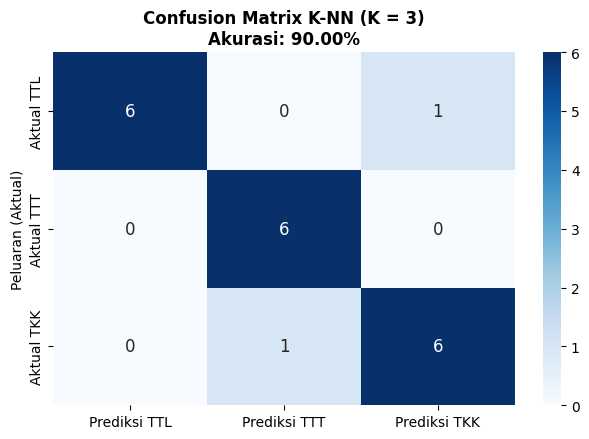


               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 5
----------------------------------------------------------------------
Akurasi Sistem : 90.00%

Classification Report:
                           precision    recall  f1-score   support

Teknik Komputer & Kendali       1.00      0.86      0.92         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
    Teknik Tenaga Listrik       0.86      0.86      0.86         7

                 accuracy                           0.90        20
                macro avg       0.90      0.90      0.90        20
             weighted avg       0.91      0.90      0.90        20



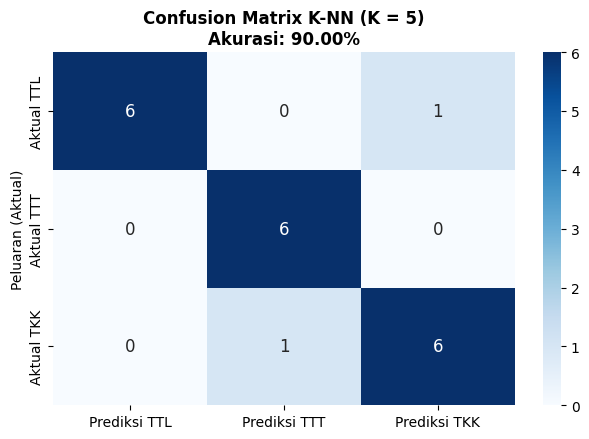


               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 7
----------------------------------------------------------------------
Akurasi Sistem : 90.00%

Classification Report:
                           precision    recall  f1-score   support

Teknik Komputer & Kendali       1.00      0.86      0.92         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
    Teknik Tenaga Listrik       0.86      0.86      0.86         7

                 accuracy                           0.90        20
                macro avg       0.90      0.90      0.90        20
             weighted avg       0.91      0.90      0.90        20



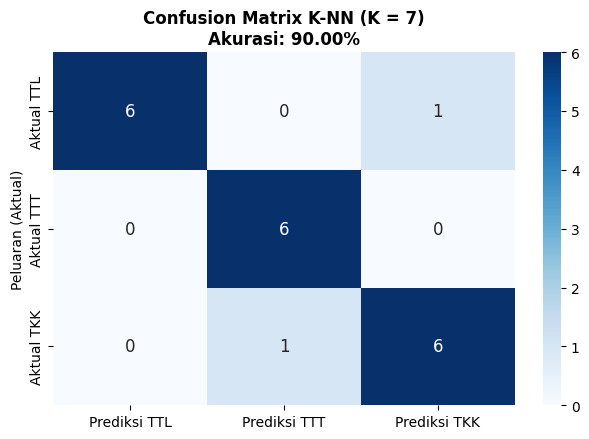


               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 9
----------------------------------------------------------------------
Akurasi Sistem : 85.00%

Classification Report:
                           precision    recall  f1-score   support

Teknik Komputer & Kendali       1.00      0.71      0.83         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
    Teknik Tenaga Listrik       0.75      0.86      0.80         7

                 accuracy                           0.85        20
                macro avg       0.87      0.86      0.85        20
             weighted avg       0.87      0.85      0.85        20



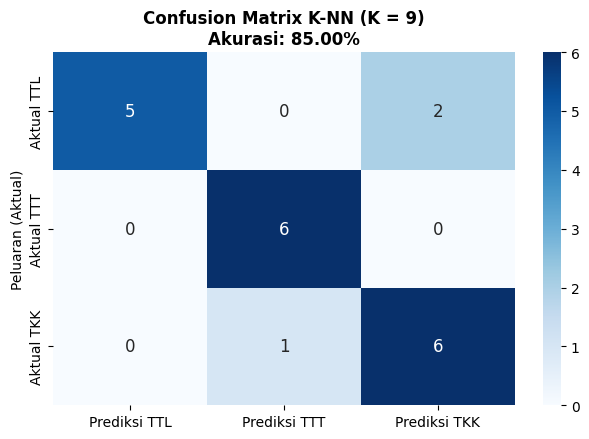


               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = 11
----------------------------------------------------------------------
Akurasi Sistem : 85.00%

Classification Report:
                           precision    recall  f1-score   support

Teknik Komputer & Kendali       1.00      0.71      0.83         7
    Teknik Telekomunikasi       0.86      1.00      0.92         6
    Teknik Tenaga Listrik       0.75      0.86      0.80         7

                 accuracy                           0.85        20
                macro avg       0.87      0.86      0.85        20
             weighted avg       0.87      0.85      0.85        20



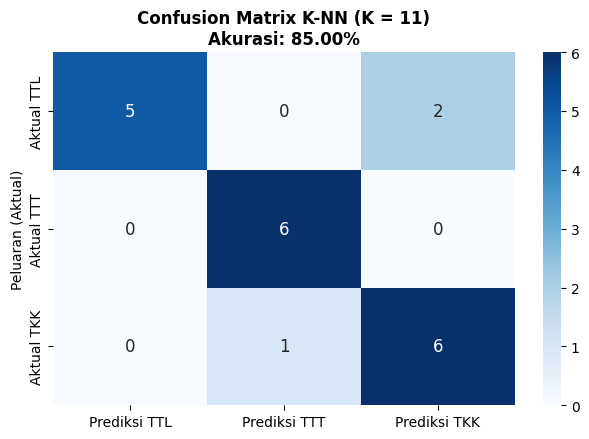

In [8]:
#7: EVALUASI MODEL (CLASSIFICATION REPORT & CONFUSION MATRIX)
list_k = [3, 5, 7, 9, 11]
labels_unik = sorted(list(set(y_train)))

labels_singkat_y = ['Aktual TTL', 'Aktual TTT', 'Aktual TKK']
labels_singkat_x = ['Prediksi TTL', 'Prediksi TTT', 'Prediksi TKK']

print("\n=== BAGIAN 7: EVALUASI PERFORMA MODEL K-NN DENGAN CLASSIFICATION REPORT & CONFUSION MATRIX ===")

for k in list_k:
    y_pred_k = [prediksi_knn_tunggal(X_train, y_train, x_te, k=k)[0] for x_te in X_test]
    acc = accuracy_score(y_test, y_pred_k)
    report = classification_report(y_test, y_pred_k, target_names=labels_unik, digits=2)

    print("\n" + "="*70)
    print(f"               HASIL EVALUASI MODEL K-NN UNTUK NILAI K = {k}")
    print("-" * 70)
    print(f"Akurasi Sistem : {acc*100:.2f}%\n")
    print("Classification Report:")
    print(report)

    cm = confusion_matrix(y_test, y_pred_k, labels=labels_unik)
    plt.figure(figsize=(6.5, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_singkat_x,
                yticklabels=labels_singkat_y,
                cbar=True, annot_kws={"size": 12})
    plt.title(f'Confusion Matrix K-NN (K = {k})\nAkurasi: {acc*100:.2f}%', fontsize=12, fontweight='bold')
    plt.ylabel('Peluaran (Aktual)', fontsize=10)
    plt.yticks(rotation=90, va='center')
    plt.xticks(rotation=0, ha='center')
    plt.tight_layout()
    plt.show()

Nilai K,Fold-1 (%),Fold-2 (%),Fold-3 (%),Fold-4 (%),Fold-5 (%),Rata-rata Akurasi (%)
K = 3,75.000000,95.000000,90.000000,100.000000,90.000000,90.000000
K = 5,80.000000,90.000000,90.000000,100.000000,90.000000,90.000000
K = 7,85.000000,90.000000,90.000000,100.000000,90.000000,91.000000
K = 9,85.000000,85.000000,90.000000,100.000000,90.000000,90.000000
K = 11,85.000000,90.000000,100.000000,100.000000,90.000000,93.000000


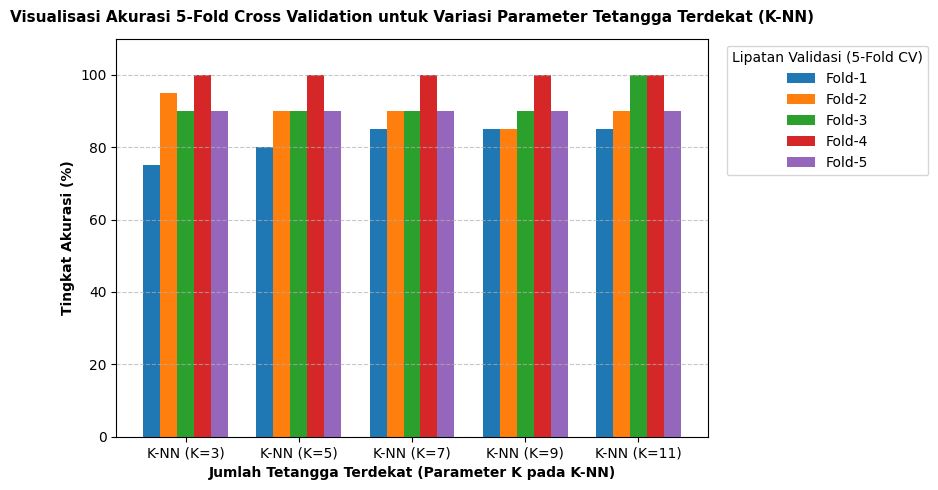

In [9]:
#8: 5-FOLD CROSS VALIDATION
df_all_scaled = preprocess_and_scale(df)
X_all = df_all_scaled[kolom_fitur].values
y_all = df_all_scaled[kolom_target].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dict_fold_acc = {f"Fold-{i+1} (%)": [] for i in range(5)}
dict_fold_acc['Nilai K'] = [f"K = {k}" for k in list_k]

for k in list_k:
    fold_idx = 0
    for train_index, test_index in skf.split(X_all, y_all):
        X_tr_f, X_te_f = X_all[train_index], X_all[test_index]
        y_tr_f, y_te_f = y_all[train_index], y_all[test_index]
        y_pred_f = [prediksi_knn_tunggal(X_tr_f, y_tr_f, x_val, k=k)[0] for x_val in X_te_f]
        acc_f = accuracy_score(y_te_f, y_pred_f) * 100
        dict_fold_acc[f"Fold-{fold_idx+1} (%)"].append(round(acc_f, 2))
        fold_idx += 1

df_cv_all = pd.DataFrame(dict_fold_acc)
fold_cols = [f"Fold-{i+1} (%)" for i in range(5)]
df_cv_all['Rata-rata Akurasi (%)'] = df_cv_all[fold_cols].mean(axis=1).round(2)
df_cv_tabel = df_cv_all[['Nilai K'] + fold_cols + ['Rata-rata Akurasi (%)']]

display(HTML("<br><b>=== BAGIAN 8: HASIL 5-FOLD CROSS VALIDATION UNTUK SETIAP NILAI K ===</b>"))
display(HTML("<b>Tabel 7.1: Rekapitulasi Akurasi Cross Validation Tiap Fold (100 Data):</b>"))
display(df_cv_tabel.style.hide(axis='index'))

# Visualisasi Bar Chart Cross Validation dengan Label Jelas
plt.figure(figsize=(9, 5))
x = np.arange(len(list_k))
width = 0.15
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i in range(5):
    plt.bar(x + (i - 2) * width, df_cv_all[f"Fold-{i+1} (%)"], width=width, label=f'Fold-{i+1}', color=colors[i])

plt.title('Visualisasi Akurasi 5-Fold Cross Validation untuk Variasi Parameter Tetangga Terdekat (K-NN)', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Jumlah Tetangga Terdekat (Parameter K pada K-NN)', fontsize=10, fontweight='bold')
plt.ylabel('Tingkat Akurasi (%)', fontsize=10, fontweight='bold')
plt.xticks(x, [f'K-NN (K={k})' for k in list_k])
plt.ylim(0, 110)
plt.legend(title='Lipatan Validasi (5-Fold CV)', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()